In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    pairwise_distances,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

In [2]:
ORIGINAL_DATA_PATH ="student-mat.csv"
ORIGINAL_SEPARATOR = ";"

SYNTHETIC_DATA_PATHS = {
    "synthetic_distill": "synthetic_students_typed.csv",
    "synthetic_opt125": "synthetic_students_typed_opt.csv",
    "synthetic_opt350": "synthetic_students_typed_opt250.csv",
    "synthetic_opt1.3b": "synthetic_students_typed_opt13b.csv",
}
SYNTHETIC_SEPARATOR = ","
SAVE_RESULTS_PATH = "synthetic_privacy_metrics.csv"
MAKE_MIA_PLOTS = True
PLOT_DIR = "plots"


TRAIN_SIZE = 300
TEST_SIZE = 95
RANDOM_STATE = 42

ATTRIBUTE_INFERENCE_CLASSIFICATION = {
    "enabled": True,
    "known_features": [
        "age",
        "famsize",
        "Pstatus",
        "Medu",
        "Fedu",
        "studytime",
    ],
    "sensitive_attribute": "address",
}

ATTRIBUTE_INFERENCE_REGRESSION = {
    "enabled": True,
    "known_features": [
        "address",
        "famsize",
        "Medu",
        "Fedu",
        "studytime",
        "failures",
        "absences",
    ],
    "sensitive_attribute": "G3",
}
SHADOW_MIA = {
    "enabled": True,
    "target_column": "G3",
    "n_shadow_models": 3,
    "shadow_test_size": 0.5,
    "attack_test_size": 0.25,
    "random_state": 42,
    "bin_numeric_target": True,
    "n_bins": 3,
}

In [3]:
def clean_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = (
        df.columns
        .astype(str)
        .str.replace("\ufeff", "", regex=False)
        .str.strip()
    )
    return df


def read_original_dataset(path: str) -> pd.DataFrame:
    return clean_columns(pd.read_csv(path, sep=ORIGINAL_SEPARATOR))


def read_synthetic_dataset(path: str) -> pd.DataFrame:
    return clean_columns(pd.read_csv(path, sep=SYNTHETIC_SEPARATOR))


def maybe_make_dir(path: str):
    if path:
        os.makedirs(path, exist_ok=True)


def get_num_cat_columns(df: pd.DataFrame):
    num_cols = df.select_dtypes(include=np.number).columns.tolist()
    cat_cols = [c for c in df.columns if c not in num_cols]
    return num_cols, cat_cols


def common_columns(*dfs: pd.DataFrame) -> list:
    if not dfs:
        return []
    common = set(dfs[0].columns)
    for df in dfs[1:]:
        common &= set(df.columns)
    return [c for c in dfs[0].columns if c in common]


def keep_common_columns(*dfs: pd.DataFrame):
    cols = common_columns(*dfs)
    if not cols:
        raise ValueError("No common columns between the provided datasets.")
    return tuple(df[cols].copy() for df in dfs)


def require_columns(df: pd.DataFrame, required_cols: list, dataset_name: str):
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"{dataset_name} is missing columns: {missing}")


def make_classification_target(
    y: pd.Series,
    bin_numeric_target: bool = True,
    n_bins: int = 3,
) -> pd.Series:
    y = y.copy()
    if pd.api.types.is_numeric_dtype(y) and bin_numeric_target:
        return pd.qcut(y, q=n_bins, duplicates="drop").astype(str)
    return y.astype(str)


def build_feature_preprocessor(df_features: pd.DataFrame):
    num_cols, cat_cols = get_num_cat_columns(df_features)

    return ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
        ],
        remainder="drop",
    )


def make_rf_classifier(random_state: int = 42) -> RandomForestClassifier:
    return RandomForestClassifier(n_estimators=100, random_state=random_state)


def make_rf_regressor(random_state: int = 42) -> RandomForestRegressor:
    return RandomForestRegressor(n_estimators=100, random_state=random_state)


def make_rf_pipeline(X: pd.DataFrame, random_state: int = 42) -> Pipeline:
    return Pipeline([
        ("preprocessor", build_feature_preprocessor(X)),
        ("model", make_rf_classifier(random_state=random_state)),
    ])


def align_feature_sets(*dfs: pd.DataFrame):
    cols = common_columns(*dfs)
    if not cols:
        raise ValueError("No common feature columns between the provided datasets.")
    return tuple(df[cols].copy() for df in dfs)


def split_features_target(df: pd.DataFrame, target_column: str):
    require_columns(df, [target_column], "dataset")
    X = df.drop(columns=[target_column]).copy()
    y = df[target_column].copy()
    return X, y


def encode_feature_splits(*feature_dfs: pd.DataFrame):
    lengths = [len(df) for df in feature_dfs]
    combined = pd.concat(feature_dfs, axis=0, ignore_index=True)
    encoded = pd.get_dummies(combined, drop_first=False)

    splits = []
    start = 0
    for length in lengths:
        stop = start + length
        splits.append(encoded.iloc[start:stop].reset_index(drop=True))
        start = stop
    return tuple(splits)


def classification_metrics(y_true, y_pred, prefix: str) -> dict:
    return {
        f"{prefix}_acc": accuracy_score(y_true, y_pred),
        f"{prefix}_precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        f"{prefix}_recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        f"{prefix}_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }


def regression_metrics(y_true, y_pred, prefix: str) -> dict:
    return {
        f"{prefix}_mae": float(mean_absolute_error(y_true, y_pred)),
        f"{prefix}_rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        f"{prefix}_r2": float(r2_score(y_true, y_pred)),
    }


def mixed_distance_matrices(
    real_df: pd.DataFrame,
    synth_df: pd.DataFrame | None = None,
    include_real_real: bool = False,
):
    num_cols, cat_cols = get_num_cat_columns(real_df)
    synth_df = synth_df if synth_df is not None else real_df

    num_cols = [c for c in num_cols if c in synth_df.columns]
    cat_cols = [c for c in cat_cols if c in synth_df.columns]

    n_real = len(real_df)
    n_synth = len(synth_df)

    if num_cols:
        scaler = StandardScaler()
        real_num = scaler.fit_transform(real_df[num_cols])
        synth_num = scaler.transform(synth_df[num_cols])

        num_dist_sr = pairwise_distances(synth_num, real_num, metric="euclidean")
        num_dist_rr = (pairwise_distances(real_num, real_num, metric="euclidean")if include_real_real else None)
    else:
        num_dist_sr = np.zeros((n_synth, n_real))
        num_dist_rr = np.zeros((n_real, n_real)) if include_real_real else None

    if cat_cols:
        real_cat = real_df[cat_cols].astype(str).to_numpy()
        synth_cat = synth_df[cat_cols].astype(str).to_numpy()

        cat_dist_sr = (synth_cat[:, None, :] != real_cat[None, :, :]).astype(int).mean(axis=2)
        cat_dist_rr = ((real_cat[:, None, :] != real_cat[None, :, :]).astype(int).mean(axis=2)if include_real_real else None)
    else:
        cat_dist_sr = np.zeros((n_synth, n_real))
        cat_dist_rr = np.zeros((n_real, n_real)) if include_real_real else None

    dist_sr = num_dist_sr + cat_dist_sr
    dist_rr = None if not include_real_real else num_dist_rr + cat_dist_rr
    return dist_sr, dist_rr

In [4]:
def metric_mixed_closest_record(real_df: pd.DataFrame, synth_df: pd.DataFrame) -> dict:
    dist_sr, _ = mixed_distance_matrices(real_df, synth_df, include_real_real=False)
    closest_dist = dist_sr.min(axis=1)

    return {
        "mixed_distance_mean": float(closest_dist.mean()),
        "mixed_distance_min": float(closest_dist.min()),
        "mixed_distance_median": float(np.median(closest_dist)),
    }

In [9]:
def metric_nndr(real_df: pd.DataFrame, synth_df: pd.DataFrame) -> dict:
    if len(real_df) < 2:
        return {
            "nndr": np.nan,
            "nndr_min": np.nan,
            "nndr_max": np.nan,
            "nndr_std": np.nan,
            "DCR_mean": np.nan,
            "second_nn_mean": np.nan,
            "real_nn_mean": np.nan,
            "DCR_real_NN_ratio": np.nan,
        }

    total_dist, total_dist_rr = mixed_distance_matrices(
        real_df,
        synth_df,
        include_real_real=True,
    )

    nearest_two = np.partition(total_dist, kth=1, axis=1)[:, :2]
    first_nn = nearest_two.min(axis=1)
    second_nn = nearest_two.max(axis=1)

    eps = 1e-8
    nndr_values = first_nn / (second_nn + eps)

    np.fill_diagonal(total_dist_rr, np.inf)
    real_nn = total_dist_rr.min(axis=1)

    return {
        "nndr": float(np.mean(nndr_values)),
        "nndr_min": float(np.min(nndr_values)),
        "nndr_max": float(np.max(nndr_values)),
        "nndr_std": float(np.std(nndr_values)),
        "DCR_mean": float(np.mean(first_nn)),
        "second_nn_mean": float(np.mean(second_nn)),
        "real_nn_mean": float(np.mean(real_nn)),
        "DCR_real_NN_ratio": float(np.mean(first_nn) / (np.mean(real_nn) + eps)),
    }

In [11]:
def metric_membership_inference(
    D_real_train: pd.DataFrame,
    D_real_holdout: pd.DataFrame,
    D_syn: pd.DataFrame,
    dataset_name: str,
    make_plots: bool = MAKE_MIA_PLOTS,
    plot_dir: str = "plots",
) -> dict:
    D_real_train, D_real_holdout, D_syn = keep_common_columns(
        D_real_train,
        D_real_holdout,
        D_syn,
    )

    preprocessor = build_feature_preprocessor(D_real_train)
    all_df = pd.concat([D_real_train, D_real_holdout, D_syn], axis=0, ignore_index=True)
    preprocessor.fit(all_df)

    X_train = preprocessor.transform(D_real_train)
    X_holdout = preprocessor.transform(D_real_holdout)
    X_syn = preprocessor.transform(D_syn)

    dist_train = pairwise_distances(X_train, X_syn, metric="euclidean").min(axis=1)
    dist_holdout = pairwise_distances(X_holdout, X_syn, metric="euclidean").min(axis=1)

    y_true = np.concatenate([
        np.ones(len(dist_train), dtype=int),
        np.zeros(len(dist_holdout), dtype=int),
    ])
    y_score = np.concatenate([-dist_train, -dist_holdout])

    auc = roc_auc_score(y_true, y_score)
    fpr, tpr, _ = roc_curve(y_true, y_score)

    result = {
        "mia_roc_auc": float(auc),
        "mia_member_distance_mean": float(dist_train.mean()),
        "mia_nonmember_distance_mean": float(dist_holdout.mean()),
    }

    if make_plots:
        maybe_make_dir(plot_dir)

        plt.figure(figsize=(6, 6))
        plt.plot(fpr, tpr, label=f"MIA ROC (AUC = {auc:.3f})")
        plt.plot([0, 1], [0, 1], linestyle="--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"Membership Inference ROC - {dataset_name}")
        plt.legend()
        plt.tight_layout()
        plt.savefig(f"{plot_dir}/{dataset_name}_mia_roc.png", dpi=150)
        plt.show()
        plt.close()

        plt.figure(figsize=(8, 5))
        plt.hist(dist_train, bins=25, alpha=0.6, density=True, label="Members (training set)")
        plt.hist(dist_holdout, bins=25, alpha=0.6, density=True, label="Non-members (holdout set)")
        plt.xlabel("Distance to closest synthetic record")
        plt.ylabel("Density")
        plt.title(f"Distance Distribution - {dataset_name}")
        plt.legend()
        plt.tight_layout()
        plt.savefig(f"{plot_dir}/{dataset_name}_mia_hist.png", dpi=150)
        plt.show()
        plt.close()

    return result

In [62]:
def metric_attribute_inference_classification(
    D_real_train: pd.DataFrame,
    D_real_holdout: pd.DataFrame,
    D_syn: pd.DataFrame,
    known_features: list,
    sensitive_attribute: str,
) -> dict:
    required_cols = known_features + [sensitive_attribute]
    require_columns(D_real_train, required_cols, "D_real_train")
    require_columns(D_real_holdout, required_cols, "D_real_holdout")
    require_columns(D_syn, required_cols, "D_syn")

    X_syn_raw = D_syn[known_features].copy()
    X_real_train_raw = D_real_train[known_features].copy()
    X_real_test_raw = D_real_holdout[known_features].copy()

    y_syn = D_syn[sensitive_attribute].copy()
    y_real_train = D_real_train[sensitive_attribute].copy()
    y_real_test = D_real_holdout[sensitive_attribute].copy()

    X_syn, X_real_test_for_syn = encode_feature_splits(
        X_syn_raw,
        X_real_test_raw,
    )

    X_real_train, X_real_test_for_real = encode_feature_splits(
        X_real_train_raw,
        X_real_test_raw,
    )

    attacker_model_syn = make_rf_classifier(random_state=42)
    attacker_model_syn.fit(X_syn, y_syn)
    y_pred_syn_to_real = attacker_model_syn.predict(X_real_test_for_syn)
    accuracy_syn_to_real = accuracy_score(y_real_test, y_pred_syn_to_real)

    attacker_model_real = make_rf_classifier(random_state=42)
    attacker_model_real.fit(X_real_train, y_real_train)
    y_pred_real_to_real = attacker_model_real.predict(X_real_test_for_real)
    accuracy_real_to_real = accuracy_score(y_real_test, y_pred_real_to_real)

    majority_class = y_real_train.mode()[0]
    accuracy_majority = accuracy_score(y_real_test, [majority_class] * len(y_real_test))

    advantage_over_majority = accuracy_syn_to_real - accuracy_majority
    denominator = accuracy_real_to_real - accuracy_majority
    leakage_ratio = (
        max(0.0, advantage_over_majority / denominator)
        if denominator > 0
        else 0.0
    )

    return {
        "aia_cls_attack_accuracy_syn_to_real": float(accuracy_syn_to_real),
        "aia_cls_baseline_accuracy_real_to_real": float(accuracy_real_to_real),
        "aia_cls_baseline_accuracy_majority": float(accuracy_majority),
        "aia_cls_advantage_over_majority": float(advantage_over_majority),
        "aia_cls_leakage_ratio": float(leakage_ratio),
    }

In [64]:
def metric_attribute_inference_regression(
    D_real_train: pd.DataFrame,
    D_real_holdout: pd.DataFrame,
    D_syn: pd.DataFrame,
    known_features: list,
    sensitive_attribute: str,
) -> dict:
    required_cols = known_features + [sensitive_attribute]
    require_columns(D_real_train, required_cols, "D_real_train")
    require_columns(D_real_holdout, required_cols, "D_real_holdout")
    require_columns(D_syn, required_cols, "D_syn")

    X_syn_raw = D_syn[known_features].copy()
    y_syn = pd.to_numeric(D_syn[sensitive_attribute], errors="coerce")

    X_real_train_raw = D_real_train[known_features].copy()
    y_real_train = pd.to_numeric(D_real_train[sensitive_attribute], errors="coerce")

    X_real_test_raw = D_real_holdout[known_features].copy()
    y_real_test = pd.to_numeric(D_real_holdout[sensitive_attribute], errors="coerce")

    syn_mask = y_syn.notna()
    real_train_mask = y_real_train.notna()
    real_test_mask = y_real_test.notna()

    X_syn_raw = X_syn_raw.loc[syn_mask].reset_index(drop=True)
    y_syn = y_syn.loc[syn_mask].reset_index(drop=True)

    X_real_train_raw = X_real_train_raw.loc[real_train_mask].reset_index(drop=True)
    y_real_train = y_real_train.loc[real_train_mask].reset_index(drop=True)

    X_real_test_raw = X_real_test_raw.loc[real_test_mask].reset_index(drop=True)
    y_real_test = y_real_test.loc[real_test_mask].reset_index(drop=True)

    real_combined = pd.concat(
        [X_real_train_raw, X_real_test_raw],
        axis=0,
        ignore_index=True
    )

    real_encoded = pd.get_dummies(real_combined, drop_first=False)

    X_real_train = real_encoded.iloc[:len(X_real_train_raw)].reset_index(drop=True)
    X_real_test = real_encoded.iloc[len(X_real_train_raw):].reset_index(drop=True)

    X_syn = pd.get_dummies(X_syn_raw, drop_first=False)

    X_syn = X_syn.reindex(
        columns=X_real_train.columns,
        fill_value=0
    )

    attacker_model_syn = make_rf_regressor(random_state=42)
    attacker_model_syn.fit(X_syn, y_syn)

    y_pred_syn_to_real = attacker_model_syn.predict(X_real_test)

    attacker_model_real = make_rf_regressor(random_state=42)
    attacker_model_real.fit(X_real_train, y_real_train)

    y_pred_real_to_real = attacker_model_real.predict(X_real_test)


    mean_value = y_real_train.mean()
    y_pred_mean = np.full(len(y_real_test), mean_value)


    syn_metrics = regression_metrics(
        y_real_test,
        y_pred_syn_to_real,
        "aia_reg_attack_syn_to_real"
    )

    real_metrics = regression_metrics(
        y_real_test,
        y_pred_real_to_real,
        "aia_reg_baseline_real_to_real"
    )

    mean_metrics = regression_metrics(
        y_real_test,
        y_pred_mean,
        "aia_reg_baseline_mean"
    )

    mae_syn = syn_metrics["aia_reg_attack_syn_to_real_mae"]
    rmse_syn = syn_metrics["aia_reg_attack_syn_to_real_rmse"]

    mae_real = real_metrics["aia_reg_baseline_real_to_real_mae"]
    rmse_real = real_metrics["aia_reg_baseline_real_to_real_rmse"]

    mae_mean = mean_metrics["aia_reg_baseline_mean_mae"]
    rmse_mean = mean_metrics["aia_reg_baseline_mean_rmse"]

    den_mae = mae_mean - mae_real
    den_rmse = rmse_mean - rmse_real

    return {

        "aia_reg_attack_mae_syn_to_real": syn_metrics["aia_reg_attack_syn_to_real_mae"],
        "aia_reg_attack_rmse_syn_to_real": syn_metrics["aia_reg_attack_syn_to_real_rmse"],
        "aia_reg_attack_r2_syn_to_real": syn_metrics["aia_reg_attack_syn_to_real_r2"],

        "aia_reg_baseline_mae_real_to_real": real_metrics["aia_reg_baseline_real_to_real_mae"],
        "aia_reg_baseline_rmse_real_to_real": real_metrics["aia_reg_baseline_real_to_real_rmse"],
        "aia_reg_baseline_r2_real_to_real": real_metrics["aia_reg_baseline_real_to_real_r2"],

        "aia_reg_baseline_mae_mean": mean_metrics["aia_reg_baseline_mean_mae"],
        "aia_reg_baseline_rmse_mean": mean_metrics["aia_reg_baseline_mean_rmse"],
        "aia_reg_baseline_r2_mean": mean_metrics["aia_reg_baseline_mean_r2"],

        "aia_reg_advantage_mae": float(mae_mean - mae_syn),
        "aia_reg_advantage_rmse": float(rmse_mean - rmse_syn),

        "aia_reg_leakage_ratio_mae": float((mae_mean - mae_syn) / den_mae) if den_mae > 0 else 0,
        "aia_reg_leakage_ratio_rmse": float((rmse_mean - rmse_syn) / den_rmse) if den_rmse > 0 else 0,
    }

In [66]:
def metric_shadow_model_mia(
    D_real_train: pd.DataFrame,
    D_real_holdout: pd.DataFrame,
    D_syn: pd.DataFrame,
    target_column: str,
    n_shadow_models: int = 3,
    shadow_test_size: float = 0.5,
    attack_test_size: float = 0.25,
    random_state: int = 42,
    bin_numeric_target: bool = True,
    n_bins: int = 3,
) -> dict:
    require_columns(D_real_train, [target_column], "D_real_train")
    require_columns(D_real_holdout, [target_column], "D_real_holdout")
    require_columns(D_syn, [target_column], "D_syn")

    X_real_train = D_real_train.drop(columns=[target_column]).copy()
    y_real_train = make_classification_target(
        D_real_train[target_column],
        bin_numeric_target=bin_numeric_target,
        n_bins=n_bins,
    )

    X_real_holdout = D_real_holdout.drop(columns=[target_column]).copy()
    y_real_holdout = make_classification_target(
        D_real_holdout[target_column],
        bin_numeric_target=bin_numeric_target,
        n_bins=n_bins,
    )

    X_syn = D_syn.drop(columns=[target_column]).copy()
    y_syn = make_classification_target(
        D_syn[target_column],
        bin_numeric_target=bin_numeric_target,
        n_bins=n_bins,
    )

    common_feature_cols = [
        c for c in X_real_train.columns
        if c in X_real_holdout.columns and c in X_syn.columns
    ]

    if len(common_feature_cols) == 0:
        raise ValueError("No common feature columns for shadow MIA.")

    X_real_train = X_real_train[common_feature_cols].copy()
    X_real_holdout = X_real_holdout[common_feature_cols].copy()
    X_syn = X_syn[common_feature_cols].copy()

    if len(X_syn) < 20:
        raise ValueError("Synthetic dataset too small for shadow-model MIA.")

    target_model = Pipeline([
        ("preprocessor", build_feature_preprocessor(X_real_train)),
        ("model", RandomForestClassifier(n_estimators=100, random_state=random_state)),
    ])
    target_model.fit(X_real_train, y_real_train)

    target_classes = target_model.named_steps["model"].classes_

    def extract_attack_features(model, X, y_true, class_order):
        probs = model.predict_proba(X)
        model_classes = model.named_steps["model"].classes_

        aligned_probs = np.zeros((len(X), len(class_order)), dtype=float)
        model_class_to_idx = {c: i for i, c in enumerate(model_classes)}

        for j, c in enumerate(class_order):
            if c in model_class_to_idx:
                aligned_probs[:, j] = probs[:, model_class_to_idx[c]]

        y_true = pd.Series(y_true).astype(str).reset_index(drop=True)
        class_to_idx = {c: i for i, c in enumerate(class_order)}

        true_class_prob = np.array([aligned_probs[i, class_to_idx[label]] if label in class_to_idx else 0.0 for i, label in enumerate(y_true)])

        max_prob = aligned_probs.max(axis=1)
        entropy = -np.sum(aligned_probs * np.log(np.clip(aligned_probs, 1e-12, 1.0)),axis=1)

        return np.column_stack([
            max_prob,
            true_class_prob,
            entropy,
            aligned_probs
        ])

    syn_indices = np.arange(len(X_syn))
    X_attack_parts = []
    y_attack_parts = []

    for i in range(n_shadow_models):
        rs = random_state + i

        member_idx, nonmember_idx = train_test_split(
            syn_indices,
            test_size=shadow_test_size,
            random_state=rs,
            shuffle=True,
        )

        X_shadow_train = X_syn.iloc[member_idx].reset_index(drop=True)
        y_shadow_train = y_syn.iloc[member_idx].reset_index(drop=True)

        X_shadow_holdout = X_syn.iloc[nonmember_idx].reset_index(drop=True)
        y_shadow_holdout = y_syn.iloc[nonmember_idx].reset_index(drop=True)

        shadow_model = Pipeline([
            ("preprocessor", build_feature_preprocessor(X_shadow_train)),
            ("model", RandomForestClassifier(n_estimators=100, random_state=rs)),
        ])
        shadow_model.fit(X_shadow_train, y_shadow_train)

        shadow_member_features = extract_attack_features(shadow_model, X_shadow_train, y_shadow_train, target_classes)
        shadow_nonmember_features = extract_attack_features(shadow_model, X_shadow_holdout, y_shadow_holdout, target_classes)

        X_attack_parts.append(shadow_member_features)
        y_attack_parts.append(np.ones(len(shadow_member_features), dtype=int))

        X_attack_parts.append(shadow_nonmember_features)
        y_attack_parts.append(np.zeros(len(shadow_nonmember_features), dtype=int))

    X_attack = np.vstack(X_attack_parts)
    y_attack = np.concatenate(y_attack_parts)

    X_attack_train, X_attack_valid, y_attack_train, y_attack_valid = train_test_split(
        X_attack,
        y_attack,
        test_size=attack_test_size,
        random_state=random_state,
        stratify=y_attack,
    )

    attack_model = LogisticRegression(max_iter=1000, random_state=random_state)
    attack_model.fit(X_attack_train, y_attack_train)

    attack_valid_probs = attack_model.predict_proba(X_attack_valid)[:, 1]
    attack_valid_pred = attack_model.predict(X_attack_valid)

    attack_validation_accuracy = accuracy_score(y_attack_valid, attack_valid_pred)
    attack_validation_auc = roc_auc_score(y_attack_valid, attack_valid_probs)

    target_member_features = extract_attack_features(target_model, X_real_train, y_real_train, target_classes)
    target_nonmember_features = extract_attack_features(target_model, X_real_holdout, y_real_holdout, target_classes)

    X_target_attack = np.vstack([target_member_features, target_nonmember_features])
    y_target_true = np.concatenate([
        np.ones(len(target_member_features), dtype=int),
        np.zeros(len(target_nonmember_features), dtype=int),
    ])

    y_target_pred = attack_model.predict(X_target_attack)
    y_target_prob = attack_model.predict_proba(X_target_attack)[:, 1]

    shadow_mia_accuracy = accuracy_score(y_target_true, y_target_pred)
    shadow_mia_auc = roc_auc_score(y_target_true, y_target_prob)

    return {
        "shadow_mia_attack_validation_accuracy": float(attack_validation_accuracy),
        "shadow_mia_attack_validation_auc": float(attack_validation_auc),
        "shadow_mia_accuracy": float(shadow_mia_accuracy),
        "shadow_mia_auc": float(shadow_mia_auc),
        "shadow_mia_member_score_mean": float(np.mean(y_target_prob[:len(target_member_features)])),
        "shadow_mia_nonmember_score_mean": float(np.mean(y_target_prob[len(target_member_features):])),
    }

In [68]:
def metric_utility_classification(
    D_real_train: pd.DataFrame,
    D_real_holdout: pd.DataFrame,
    D_syn: pd.DataFrame,
    target_column: str,
) -> dict:
    require_columns(D_real_train, [target_column], "D_real_train")
    require_columns(D_real_holdout, [target_column], "D_real_holdout")
    require_columns(D_syn, [target_column], "D_syn")

    X_syn, y_syn = split_features_target(D_syn, target_column)
    X_real_train, y_real_train = split_features_target(D_real_train, target_column)
    X_real_test, y_real_test = split_features_target(D_real_holdout, target_column)

    X_syn, X_real_train, X_real_test = align_feature_sets(
        X_syn,
        X_real_train,
        X_real_test,
    )

    preprocessor = build_feature_preprocessor(X_real_train)
    preprocessor.fit(X_real_train)

    X_syn_enc = preprocessor.transform(X_syn)
    X_real_train_enc = preprocessor.transform(X_real_train)
    X_real_test_enc = preprocessor.transform(X_real_test)

    model_syn = make_rf_classifier(random_state=42)
    model_syn.fit(X_syn_enc, y_syn.astype(str))
    y_pred_syn = model_syn.predict(X_real_test_enc)

    model_real = make_rf_classifier(random_state=42)
    model_real.fit(X_real_train_enc, y_real_train.astype(str))
    y_pred_real = model_real.predict(X_real_test_enc)

    y_real_test = y_real_test.astype(str)
    results = {
        **classification_metrics(y_real_test, y_pred_syn, "utility_syn_to_real"),
        **classification_metrics(y_real_test, y_pred_real, "utility_real_to_real"),
    }


    results = {
        "utility_acc_syn_to_real": results["utility_syn_to_real_acc"],
        "utility_precision_syn_to_real": results["utility_syn_to_real_precision"],
        "utility_recall_syn_to_real": results["utility_syn_to_real_recall"],
        "utility_f1_syn_to_real": results["utility_syn_to_real_f1"],
        "utility_acc_real_to_real": results["utility_real_to_real_acc"],
        "utility_precision_real_to_real": results["utility_real_to_real_precision"],
        "utility_recall_real_to_real": results["utility_real_to_real_recall"],
        "utility_f1_real_to_real": results["utility_real_to_real_f1"],
    }

    results["utility_accuracy_ratio"] = (
        results["utility_acc_syn_to_real"] / results["utility_acc_real_to_real"]
        if results["utility_acc_real_to_real"] > 0 else 0
    )
    return results

In [70]:
def safe_update(row: dict, label: str, func, *args, **kwargs):
    try:
        row.update(func(*args, **kwargs))
    except Exception as e:
        print(f"{label} error: {e}")
        row[f"{label}_error"] = str(e)


def evaluate_one_synthetic_dataset(
    synth_name: str,
    synth_df: pd.DataFrame,
    real_train_df: pd.DataFrame,
    real_holdout_df: pd.DataFrame,
) -> dict:
    row = {"dataset": synth_name}
    rt_common, rh_common, syn_common = keep_common_columns(real_train_df, real_holdout_df, synth_df)
    row["n_common_columns"] = len(rt_common.columns)

    metric_jobs = [
        (
            "utility",
            metric_utility_classification,
            dict(
                D_real_train=real_train_df,
                D_real_holdout=real_holdout_df,
                D_syn=synth_df,
                target_column="studytime",
            ),
        ),
        ("mixed_distance", metric_mixed_closest_record, dict(real_df=rt_common, synth_df=syn_common)),
        ("nndr", metric_nndr, dict(real_df=rt_common, synth_df=syn_common)),
        (
            "mia",
            metric_membership_inference,
            dict(
                D_real_train=rt_common,
                D_real_holdout=rh_common,
                D_syn=syn_common,
                dataset_name=synth_name,
                make_plots=MAKE_MIA_PLOTS,
                plot_dir=PLOT_DIR,
            ),
        ),
    ]

    if ATTRIBUTE_INFERENCE_CLASSIFICATION["enabled"]:
        metric_jobs.append((
            "aia_cls",
            metric_attribute_inference_classification,
            dict(
                D_real_train=real_train_df,
                D_real_holdout=real_holdout_df,
                D_syn=synth_df,
                known_features=ATTRIBUTE_INFERENCE_CLASSIFICATION["known_features"],
                sensitive_attribute=ATTRIBUTE_INFERENCE_CLASSIFICATION["sensitive_attribute"],
            ),
        ))

    if ATTRIBUTE_INFERENCE_REGRESSION["enabled"]:
        metric_jobs.append((
            "aia_reg",
            metric_attribute_inference_regression,
            dict(
                D_real_train=real_train_df,
                D_real_holdout=real_holdout_df,
                D_syn=synth_df,
                known_features=ATTRIBUTE_INFERENCE_REGRESSION["known_features"],
                sensitive_attribute=ATTRIBUTE_INFERENCE_REGRESSION["sensitive_attribute"],
            ),
        ))

    if SHADOW_MIA["enabled"]:
        metric_jobs.append((
            "shadow_mia",
            metric_shadow_model_mia,
            dict(
                D_real_train=real_train_df,
                D_real_holdout=real_holdout_df,
                D_syn=synth_df,
                target_column=SHADOW_MIA["target_column"],
                n_shadow_models=SHADOW_MIA["n_shadow_models"],
                shadow_test_size=SHADOW_MIA["shadow_test_size"],
                attack_test_size=SHADOW_MIA["attack_test_size"],
                random_state=SHADOW_MIA["random_state"],
                bin_numeric_target=SHADOW_MIA["bin_numeric_target"],
                n_bins=SHADOW_MIA["n_bins"],
            ),
        ))

    for label, func, kwargs in metric_jobs:
        safe_update(row, label, func, **kwargs)

    return row


In [72]:
def main():
    print("Loading original dataset...")
    original_df = read_original_dataset(ORIGINAL_DATA_PATH)

    print("Splitting original dataset...")
    D_real_train, D_real_holdout = train_test_split(
        original_df,
        train_size=TRAIN_SIZE,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        shuffle=True
    )

    results = []

    for synth_name, synth_path in SYNTHETIC_DATA_PATHS.items():
        print(f"\nEvaluating {synth_name}...")
        synth_df = read_synthetic_dataset(synth_path)

        result_row = evaluate_one_synthetic_dataset(
            synth_name=synth_name,
            synth_df=synth_df,
            real_train_df=D_real_train,
            real_holdout_df=D_real_holdout,
        )

        results.append(result_row)

    results_df = pd.DataFrame(results)
    results_df = results_df.round(3)
    results_df.to_csv(SAVE_RESULTS_PATH, index=False)

    print("\nDone.")
    print(results_df)
    print(f"\nSaved results to: {SAVE_RESULTS_PATH}")



Loading original dataset...
Splitting original dataset...

Evaluating synthetic_distill...


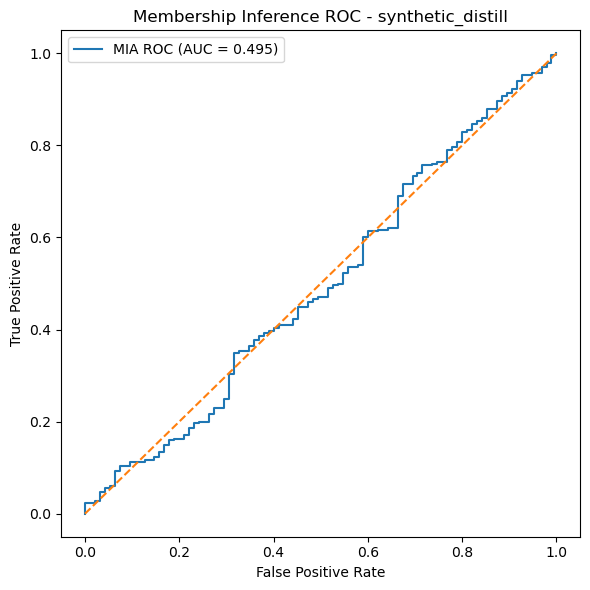

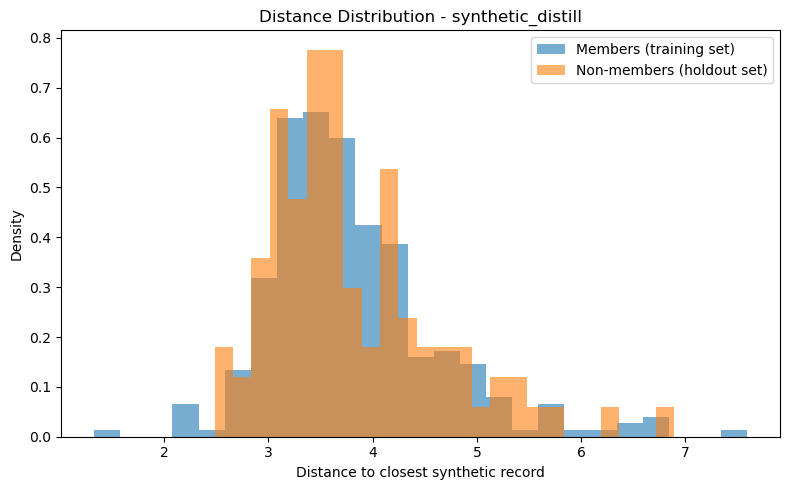


Evaluating synthetic_opt125...


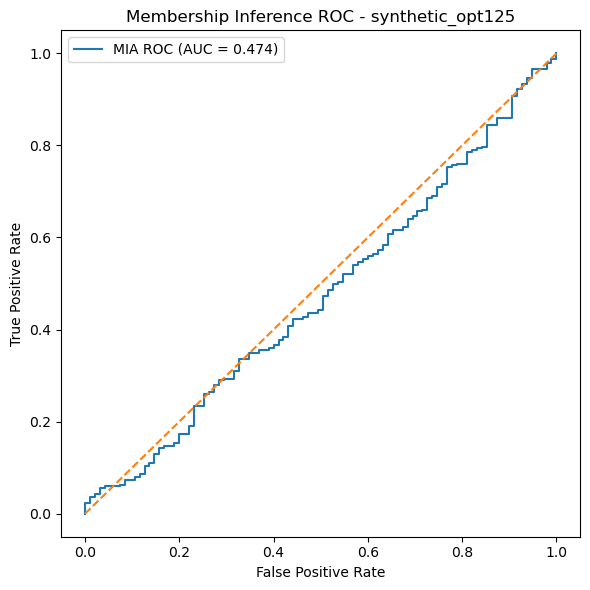

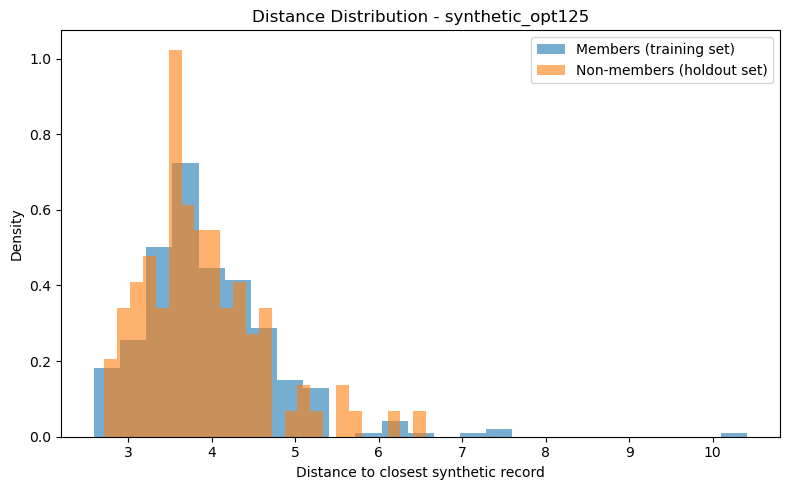


Evaluating synthetic_opt350...


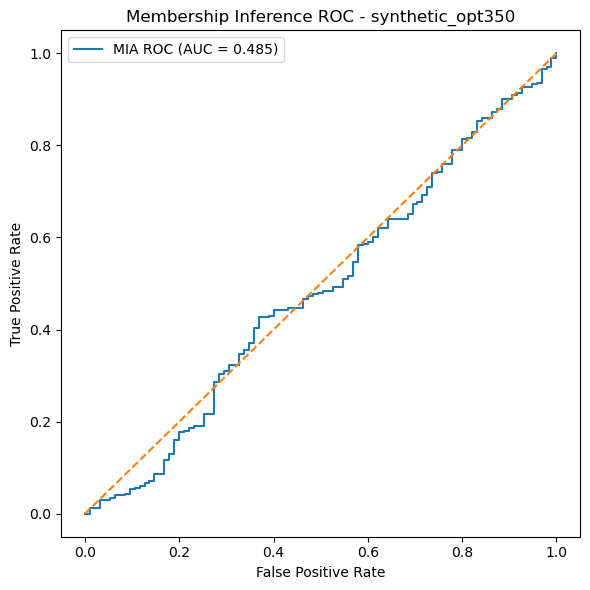

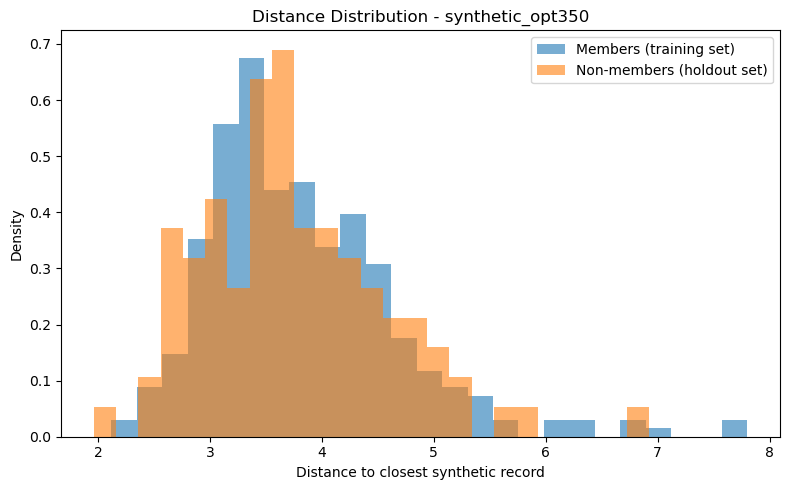


Evaluating synthetic_opt1.3b...


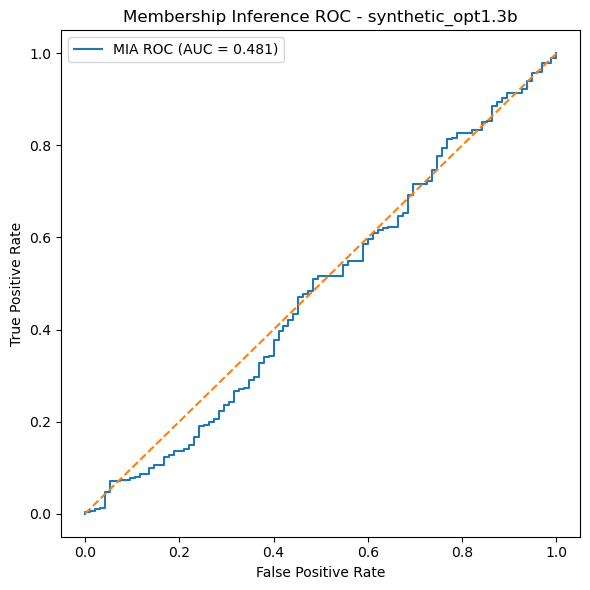

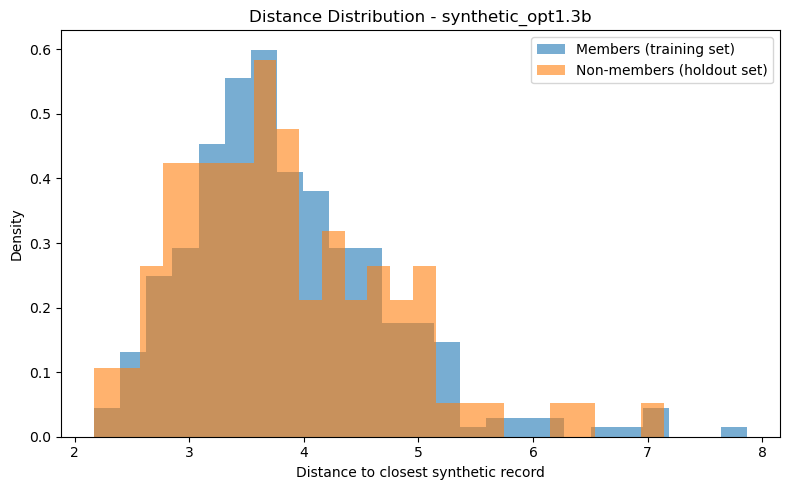


Done.
             dataset  n_common_columns  utility_acc_syn_to_real  \
0  synthetic_distill                26                    0.505   
1   synthetic_opt125                26                    0.326   
2   synthetic_opt350                26                    0.368   
3  synthetic_opt1.3b                26                    0.442   

   utility_precision_syn_to_real  utility_recall_syn_to_real  \
0                          0.408                       0.505   
1                          0.327                       0.326   
2                          0.299                       0.368   
3                          0.369                       0.442   

   utility_f1_syn_to_real  utility_acc_real_to_real  \
0                   0.357                     0.568   
1                   0.247                     0.568   
2                   0.330                     0.568   
3                   0.400                     0.568   

   utility_precision_real_to_real  utility_recall_real_to_re

In [74]:
if __name__ == "__main__":
    main()